In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import warnings

### creamos un grafo y un digrafo en blanco G y G2
Gmas = nx.Graph()
Gmenos = nx.Graph()
Gfinal= nx.Graph()

positive_edges = [
    ("A", "B", 0.0142),
    ("A", "E", 0.0047),
    ("C", "D", 0.0142),
    ("C", "E", 0.0047),
    ("E", "F", 0.0071),
    ("E", "G", 0.0071),
    ("H", "I", 0.0142),
    ("H", "J", 0.0142),
]

## añadimos una lista de aristas valoradas con nombre
Gmas.add_weighted_edges_from(positive_edges)

negative_edges = [
    ("A", "C", -0.0048),
    ("A", "D", -0.0024),
    ("A", "F", -0.0024),
    ("A", "G", -0.0024),
    ("A", "H", -0.0072),
    ("B", "C", -0.0024),
    ("B", "E", -0.0096),
    ("B", "H", -0.0024),
    ("C", "F", -0.0024),
    ("C", "G", -0.0024),
    ("C", "H", -0.0072),
    ("D", "E", -0.0096),
    ("D", "H", -0.0024),
    ("E", "H", -0.0048),
    ("F", "H", -0.0024),
    ("G", "H", -0.0024),
    ("I", "J", -0.0142),
]

alpha1=0.5
alpha2=0.5
Amenos=0.0048+0.0024+0.0024+0.0024+0.0072+0.0024+0.0096+0.0024+0.0024+0.0024+0.0072+0.0096+0.0024+0.0048+0.0024+0.0024+0.0142
Amas=0.0142+0.0047+0.0142+0.0047+0.0071+0.0071+0.0142+0.0142
Pmas=Amas/(Amas+Amenos)
Pmenos=Amenos/(Amas+Amenos)
coefmas=alpha1*Pmas/Amas
coefmenos=alpha2*Pmenos/(45*0.0096-Amenos)
ctePositivos = coefmenos*0.0096 #para sumar a las aristas positivas

Maristas=  [
    ("A", "B", coefmas*0.0142+ctePositivos),
    ("A", "C", ctePositivos-0.0048*coefmenos),
    ("A", "D", ctePositivos-0.0024*coefmenos),
    ("A", "E", coefmas*0.0047+ctePositivos),
    ("A", "F", ctePositivos-0.0024*coefmenos),
    ("A", "G", ctePositivos-0.0024*coefmenos),
    ("A", "H", ctePositivos-0.0072*coefmenos),
    ("A", "I", ctePositivos),
    ("A", "J", ctePositivos),
    
    
    ("B", "C", ctePositivos-0.0024*coefmenos),
    ("B", "D", ctePositivos),
    ("B", "E", ctePositivos-0.0096*coefmenos),
    ("B", "F", ctePositivos),
    ("B", "G", ctePositivos),
    ("B", "H", ctePositivos-0.0024*coefmenos),
    ("B", "I", ctePositivos),
    ("B", "J", ctePositivos),

    ("C", "D", coefmas*0.0142+ctePositivos),
    ("C", "E", coefmas*0.0047+ctePositivos),
    ("C", "F", ctePositivos-0.0024*coefmenos),
    ("C", "G", ctePositivos-0.0024*coefmenos),
    ("C", "H", ctePositivos-0.0072*coefmenos),
    ("C", "I", ctePositivos),
    ("C", "J", ctePositivos),

    ("D", "E", ctePositivos-0.0096*coefmenos),
    ("D", "F", ctePositivos),
    ("D", "G", ctePositivos),
    ("D", "H", ctePositivos-0.0024*coefmenos),
    ("D", "I", ctePositivos),
    ("D", "J", ctePositivos),

    ("E", "F", coefmas*0.0071+ctePositivos),
    ("E", "G", coefmas*0.0071+ctePositivos),
    ("E", "H", ctePositivos-0.0048*coefmenos),
    ("E", "I", ctePositivos),
    ("E", "J", ctePositivos),

    ("F", "G", ctePositivos),
    ("F", "H", ctePositivos-0.0024*coefmenos),
    ("F", "I", ctePositivos),
    ("F", "J", ctePositivos),
    
    ("G", "H", ctePositivos-0.0024*coefmenos),
    ("G", "I", ctePositivos),
    ("G", "J", ctePositivos),

    ("H", "I", coefmas*0.0142+ctePositivos),
    ("H", "J", coefmas*0.0142+ctePositivos),

    ("I", "J", ctePositivos-0.0142*coefmenos)
]

## añadimos una lista de aristas valoradas con nombre
Gmenos.add_weighted_edges_from(negative_edges)
Gfinal.add_weighted_edges_from(Maristas)
AdyMenos = nx.adjacency_matrix(Gmenos, weight='weight')
print(Gmenos.nodes)
print(AdyMenos)

['A', 'C', 'D', 'F', 'G', 'H', 'B', 'E', 'I', 'J']
<Compressed Sparse Row sparse array of dtype 'float64'
	with 34 stored elements and shape (10, 10)>
  Coords	Values
  (0, 1)	-0.0048
  (0, 2)	-0.0024
  (0, 3)	-0.0024
  (0, 4)	-0.0024
  (0, 5)	-0.0072
  (1, 0)	-0.0048
  (1, 3)	-0.0024
  (1, 4)	-0.0024
  (1, 5)	-0.0072
  (1, 6)	-0.0024
  (2, 0)	-0.0024
  (2, 5)	-0.0024
  (2, 7)	-0.0096
  (3, 0)	-0.0024
  (3, 1)	-0.0024
  (3, 5)	-0.0024
  (4, 0)	-0.0024
  (4, 1)	-0.0024
  (4, 5)	-0.0024
  (5, 0)	-0.0072
  (5, 1)	-0.0072
  (5, 2)	-0.0024
  (5, 3)	-0.0024
  (5, 4)	-0.0024
  (5, 6)	-0.0024
  (5, 7)	-0.0048
  (6, 1)	-0.0024
  (6, 5)	-0.0024
  (6, 7)	-0.0096
  (7, 2)	-0.0096
  (7, 5)	-0.0048
  (7, 6)	-0.0096
  (8, 9)	-0.0142
  (9, 8)	-0.0142


In [2]:
import networkx as nx


''' Louvain '''

from networkx.algorithms import community
import networkx.algorithms.community as nx_comm

LouvainMejorFinal=nx_comm.louvain_communities(Gfinal, weight='weight', resolution=1,seed=42)
print(LouvainMejorFinal)


modularidad_Lo= nx_comm.modularity(Gfinal, LouvainMejorFinal, weight='weight', resolution=1)
num_communities = len(LouvainMejorFinal)
print("Number of communities:", num_communities)

print('la modularidad para lovain es  ' , modularidad_Lo)

[{'A', 'B'}, {'C', 'D'}, {'G', 'F', 'E'}, {'J', 'H', 'I'}]
Number of communities: 4
la modularidad para lovain es   0.2684627672971175


/tmp/ipykernel_7191/552080375.py:59: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20c_r", len(communities))


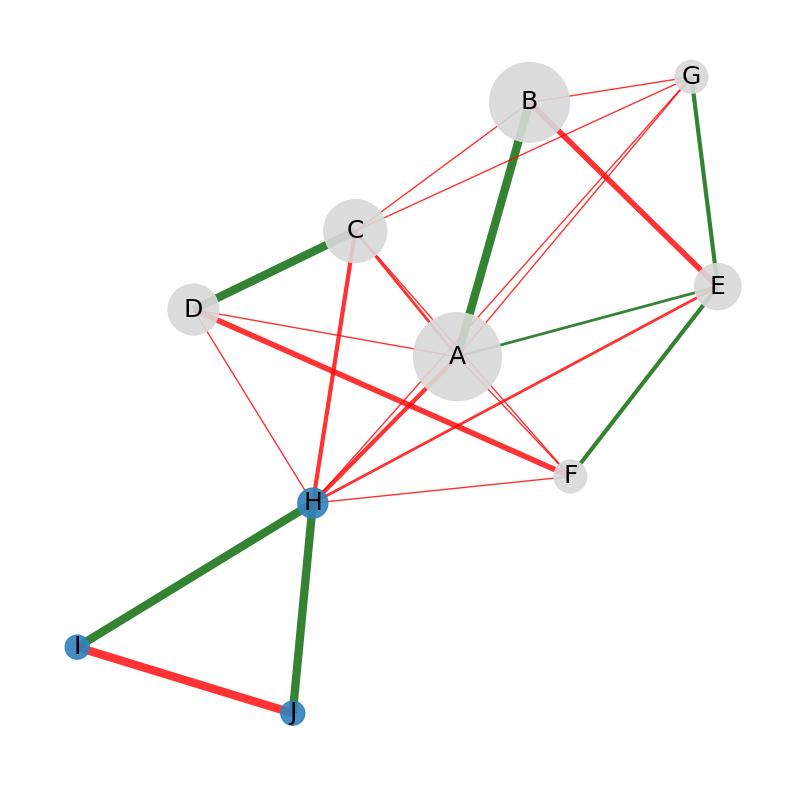

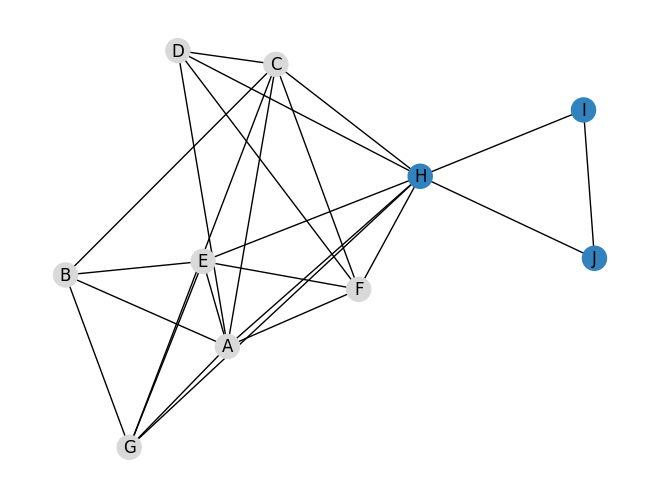

In [3]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx.algorithms.community as nx_comm

# -------------------------------------------------
# 1. DATA
# -------------------------------------------------
nodes = ["A","B","C","D","E","F","G","H","I","J"]

Sh = np.array([
    0.3226, 0.2615, 0.1559, 0.0948, 0.0753,
    0.0281, 0.0281, 0.0206, 0.0063, 0.0063
])

I = np.array([
    [ 0,      0.0142,-0.0048,-0.0024, 0.0047,-0.0024,-0.0024,-0.0072, 0,      0     ],
    [ 0.0142, 0,     -0.0024, 0,     -0.0096, 0,      -0.0024, 0,      0,      0     ],
    [-0.0048,-0.0024, 0,      0.0142, 0,     -0.0024,-0.0024,-0.0072, 0,      0     ],
    [-0.0024, 0,      0.0142, 0,      0,     -0.0096, 0,     -0.0024, 0,      0     ],
    [ 0.0047,-0.0096, 0,      0,      0.0096, 0.0071, 0.0071,-0.0048, 0,      0     ],
    [-0.0024, 0,     -0.0024, 0,      0.0071, 0,      0,     -0.0024, 0,      0     ],
    [-0.0024, 0,     -0.0024, 0,      0.0071, 0,      0,     -0.0024, 0,      0     ],
    [-0.0072,-0.0024,-0.0072,-0.0024,-0.0048,-0.0024,-0.0024, 0,      0.0142, 0.0142],
    [ 0,      0,      0,      0,      0,      0,      0,      0.0142, 0,     -0.0142],
    [ 0,      0,      0,      0,      0,      0,      0,      0.0142,-0.0142, 0     ]
])

node_to_idx = {node: i for i, node in enumerate(nodes)}

# -------------------------------------------------
# 2. BUILD GRAPH
# -------------------------------------------------
G = nx.Graph()
G.add_nodes_from(nodes)

for i in range(len(nodes)):
    for j in range(i + 1, len(nodes)):
        if I[i, j] != 0:
            G.add_edge(
                nodes[i],
                nodes[j],
                weight=abs(I[i, j]),
                sign="positive" if I[i, j] > 0 else "negative"
            )

# -------------------------------------------------
# 3. LOUVAIN PARTITION
# -------------------------------------------------
communities = nx_comm.louvain_communities(Gfinal, weight='weight', resolution=0.65,seed=42)

community_map = {}
for cid, comm in enumerate(communities):
    for node in comm:
        community_map[node] = cid

# Use bright, distinctive colors (tab30)
cmap = cm.get_cmap("tab20c_r", len(communities))
node_colors = [cmap(community_map[n]) for n in G.nodes()]
# -------------------------------------------------
# 4. NODE SIZES (ensure minimum size)
# -------------------------------------------------
min_size = 300     # minimum node size
max_size = 4000    # maximum node size

# normalize SHAP to range min_size..max_size
sh_norm = (Sh - Sh.min()) / (Sh.max() - Sh.min())
node_sizes = min_size + sh_norm * (max_size - min_size)

# -------------------------------------------------
# 5. EDGE VISUALS
# -------------------------------------------------
edge_weights = [6 * d["weight"] / max(nx.get_edge_attributes(G, "weight").values())
                for _, _, d in G.edges(data=True)]
edge_colors = ["darkgreen" if d["sign"] == "positive" else "red" for _, _, d in G.edges(data=True)]

# -------------------------------------------------
# 6. DRAW
# -------------------------------------------------
pos = nx.spring_layout(G, seed=11)

plt.figure(figsize=(10, 10))
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.9)
nx.draw_networkx_edges(G, pos, width=edge_weights, edge_color=edge_colors, alpha=0.8)
nx.draw_networkx_labels(G, pos, font_size=18)
plt.axis("off")
plt.show()

plt.savefig("grafo_parlamentario_resolution065.png", dpi=300, bbox_inches='tight')
#### Pintar de JAVIER


nx.draw(G, node_color=node_colors, with_labels=True)
plt.show()